In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

In [11]:
# Constantes
G = 6.7 * (10**(-11))  # Constante gravitacional
L = 10**5            # Momento angular
c = 0.01
m1 = 5 * (10**24)      # Massa do corpo 1
m2 = 7 * (10**23)      # Massa do corpo 2
k = G * (m1 + m2)
e = 0.8
p = (L**2) / k

# Tempo
T = 1000
dt = 1
t = np.arange(0, T, dt)

# Função para calcular o raio
def r(t):
    return p / (1 + e * np.cos(c * t))

In [4]:
# Converter para coordenadas cartesianas
def get_positions(t):
    r_t = r(t)
    x = r_t * np.cos(c * t)
    y = r_t * np.sin(c * t)
    return x, y

# Posições relativas
x_rel, y_rel = get_positions(t)

In [5]:
# Posições absolutas (considerando centro de massa)
x1 = (m2 / (m1 + m2)) * x_rel
y1 = (m2 / (m1 + m2)) * y_rel
x2 = (m1 / (m1 + m2)) * x_rel
y2 = (m1 / (m1 + m2)) * y_rel

cm_x = np.zeros_like(t)
cm_y = np.zeros_like(t)

In [6]:
# Ajustar limites do gráfico com base nos valores máximos e mínimos
x_min = min(np.min(x1), np.min(x2))
x_max = max(np.max(x1), np.max(x2))
y_min = min(np.min(y1), np.min(y2))
y_max = max(np.max(y1), np.max(y2))
margin = 0.1 * max(x_max - x_min, y_max - y_min)

GIF salvo em: /content/dois_corpos.gif


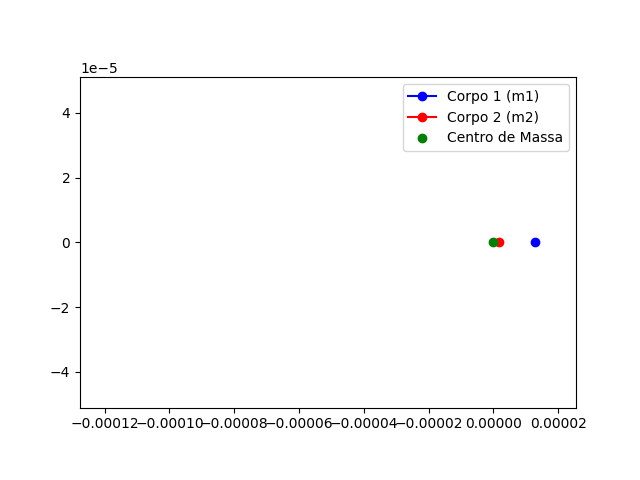

In [12]:
# Configurar a figura
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.set_xlim(x_min - margin, x_max + margin)
ax.set_ylim(y_min - margin, y_max + margin)

# Ajuste as cores e os labels de acordo com as massas
l2, = ax.plot([], [], 'bo-', label='Corpo 1 (m1)')
l1, = ax.plot([], [], 'ro-', label='Corpo 2 (m2)')
cm, = ax.plot([], [], 'go', label='Centro de Massa')
ax.legend()

def animate(i):
    l1.set_data(x1[:i], y1[:i])
    l2.set_data(x2[:i], y2[:i])
    cm.set_data(cm_x[:i], cm_y[:i])
    return l1, l2, cm

frames_seq = range(1, len(t), 10)
anim = FuncAnimation(fig, animate, frames=frames_seq, blit=True)
output_path = "/content/dois_corpos.gif"
anim.save(output_path, writer=PillowWriter(fps=30))
plt.close(fig)
print(f"GIF salvo em: {output_path}")
with open(output_path, 'rb') as f:
    display(Image(data=f.read(), format='gif'))